In [3]:
using Plots, LaTeXStrings, StatsBase

In [4]:
# sinh(mν)/sinh(nν), m ≤ n, stable for complex ν (sinh is odd ⇒ invariant under ν→−ν)
function sinhratio(m, n, ν)
    ν = real(ν) < 0 ? -ν : ν
    return exp((m - n) * ν) * expm1(-2m * ν) / expm1(-2n * ν)
end

function agpnorm(dA, J, h, γ)
    g = h * sqrt(ComplexF64(1 - γ^2))
    ν = log(J / g)                       # ln(J/g); real for γ<1, Im = ∓π/2 for γ>1
    s = 0.0
    for k in 1:dA
        s += abs2(sinhratio(dA + 1 - k, dA + 1, ν))   # |sₖ/S|²
    end
    return s / (32 * abs2(g))             # 1/(32|g|²) · Σ|sₖ/S|² = Σ|αₖ|²
end

agpnorm (generic function with 1 method)

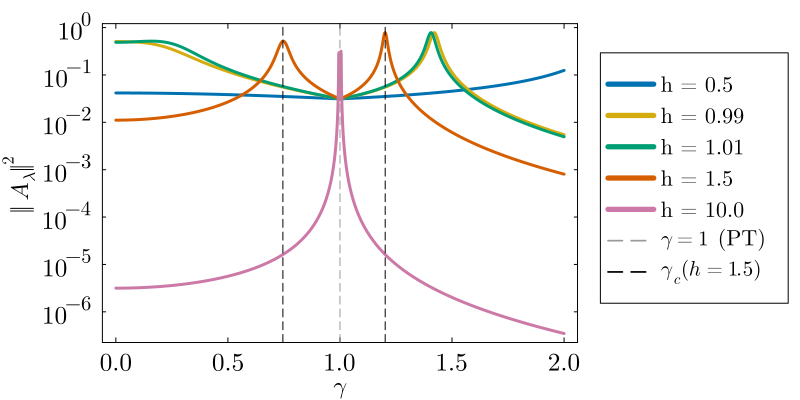

"/Users/ankit.wenjushrestha/STA_non_Hermitian_Krylov/AGP_NHTFIM.pdf"

In [ ]:
dA = 50
J  = 1.0
hs = [0.5, 0.99, 1.01, 1.5,10.0]
# Okabe-Ito colorblind-friendly palette
cols = [colorant"#0072B2",colorant"#D4AC0D",colorant"#009E73",colorant"#D55E00",colorant"#CC79A7"]

γs = range(0, 2, length=2000)

plt = plot(yscale=:log10,
    xlabel=L"\gamma", ylabel=L"\Vert A_\lambda \Vert^2",
    framestyle=:box,
    fontfamily="Computer Modern", grid=false,
    legend=:outerright, legendcolumns=1, extra_kwargs = Dict(:subplot => Dict(:legend_hfactor => 1.3)), size = (800,400),
    top_margin=4Plots.mm, left_margin=4Plots.mm, bottom_margin=3Plots.mm)


for (h, c) in zip(hs, cols)
    plot!(plt, γs, [agpnorm(dA, J, h, γ) for γ in γs],
        lw=3.0, color=c, label="h = $h")
end

plot!(plt,titlefontsize=18, guidefontsize=16, tickfontsize=16, legendfontsize=14, labelfontsize = 16, fontfamily = "Computer Modern")

vline!(plt, [1.0], ls=:dash, color=colorant"#999999", lw=1, label=L"$\gamma = 1$ (PT)  ")
vline!(plt, [sqrt(1-(1/(1.5^2)))], ls=:dash, color=colorant"#000000", lw=1, label=L"$\gamma_{c}(h = 1.5)$")
vline!(plt, [sqrt(1+(1/(1.5^2)))], ls=:dash, color=colorant"#000000", lw=1, label="")
display(plt)

#savefig(plt, "AGP_NHTFIM.pdf")